In [1]:
import pandas as pd
import joblib

# Load data
df = pd.read_csv("../data/final_processed.csv")

# Load vectorizer
tfidf = joblib.load("../models/tfidf_vectorizer.pkl")

# Prepare data
X = tfidf.transform(df['processed_text'])
y = df['label']

Train-Test Split

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Logistic Regression

In [3]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train, y_train)   # ✅ THIS IS MANDATORY

y_pred_lr = model_lr.predict(X_test)

Train Naive Bayes

In [4]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)
y_pred_nb = model_nb.predict(X_test)

Train Random Forest

In [5]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

Accuracy Comparison

In [6]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Naive Bayes:", accuracy_score(y_test, y_pred_nb))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Logistic Regression: 0.9856347438752784
Naive Bayes: 0.9314031180400891
Random Forest: 0.9971046770601336


Detailed Evaluation

In [7]:
from sklearn.metrics import classification_report

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

print("=== Naive Bayes ===")
print(classification_report(y_test, y_pred_nb))

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4710
           1       0.98      0.99      0.98      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

=== Naive Bayes ===
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      4710
           1       0.93      0.92      0.93      4270

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4710
           1       1.00      1.00      1.00      4270

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weig

Confusion Matrix (VISUAL)

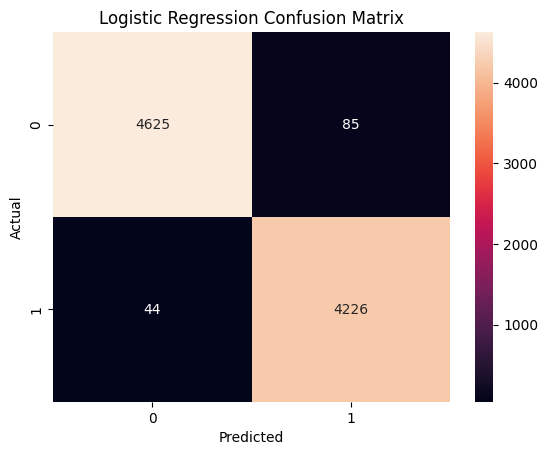

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Select Best Model

In [9]:
best_model = model_lr

Save Final Model

In [10]:
joblib.dump(best_model, "../models/fake_news_model.pkl")

['../models/fake_news_model.pkl']

NOW DO PROPER OPTIMIZATION

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'C': 10, 'solver': 'liblinear'}
Best Score: 0.9926220758490956


In [12]:
best_model = grid.best_estimator_

In [13]:
import joblib
joblib.dump(best_model, "../models/fake_news_model.pkl")

['../models/fake_news_model.pkl']

Train Final Model with Best Params And Evaluate Final Model

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


final_model = LogisticRegression(
    C=10,
    solver='liblinear',
    max_iter=1000
)

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9929844097995546
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4710
           1       0.99      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



Save Model + Vectorizer

In [15]:
import joblib

joblib.dump(final_model, "../models/fake_news_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']

Save Full Pipeline

In [16]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf', tfidf),
    ('model', final_model)
])

joblib.dump(pipeline, "../models/full_pipeline.pkl")

['../models/full_pipeline.pkl']